## Graph WaveNet — Training Pipeline
`train.ipynb` | Tomaz Cavalcante

**Requires (same directory):**
- `model.ipynb`
- `data/sensor_graph/adj_mx.pkl`  (or `adj_mx_bay.pkl` for PEMS-BAY)
- `data/METR-LA.h5`               (or `PEMS-BAY.h5`)

**Pipeline overview:**
1. Load and preprocess data (70 / 10 / 20 split, StandardScaler)
2. Instantiate Graph WaveNet from `model.ipynb`
3. Train with masked MAE loss + gradient clipping + ReduceLROnPlateau
4. Save best checkpoint; early stopping
5. Evaluate on test set — MAE, RMSE, MAPE per horizon step
6. Plot training curves and sample predictions

In [31]:
import os, time
import random
import pickle
import h5py

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.sparse as sp
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {DEVICE}')

device: cuda


## Configuration

All hyperparameters live in a single `CONFIG` dict for easy experimentation.

In [32]:
CONFIG = {
    # -- Data ------------------------------------------------------------------
    'adj_file'   : 'data/adj_METR-LA.pkl',  # METR-LA graph
    'data_file'  : 'data/metr-la.h5',               # speed readings
    'num_nodes'  : 207,     # 207 for METR-LA | 325 for PEMS-BAY
    'seq_len'    : 12,      # input window  (12 x 5 min = 1 hr of history)
    'horizon'    : 12,      # output window (12 x 5 min = 1 hr forecast)
    'batch_size' : 64,

    # -- Model -----------------------------------------------------------------
    'in_channels'       : 1,
    'out_channels'      : 12,
    'residual_channels' : 32,
    'skip_channels'     : 256,
    'end_channels'      : 512,
    'kernel_size'       : 2,
    'n_blocks'          : 4,
    'n_layers'          : 2,
    'gcn_depth'         : 2,
    'dropout'           : 0.3,
    'embed_dim'         : 10,

    # -- Training --------------------------------------------------------------
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,
    'n_epochs'       : 100,
    'patience'       : 15,    # early stopping: max consecutive non-improving epochs
    'clip_grad'      : 5.0,   # max gradient norm (prevents GCN instability)
    'checkpoint_dir' : 'checkpoints',
}

## Data Loading

Utility functions copied from `utilities.ipynb` — `train.ipynb` is self-contained for data loading.

In [33]:
# -- load_adj_matrix ----------------------------------------------------------
def load_adj_matrix(pkl_filename):
    with open(pkl_filename, 'rb') as f:
        _, _, adj_mx = pickle.load(f, encoding='latin1')   # legacy Python 2 format

    # Random-walk normalisation: D^-1 A  (each row sums to 1)
    row_sums = np.array(adj_mx.sum(axis=1))
    d_inv = np.power(row_sums, -1).flatten()
    d_inv[np.isinf(d_inv)] = 0.
    normalized_adj = sp.diags(d_inv).dot(sp.coo_matrix(adj_mx))

    coo     = normalized_adj.tocoo()
    indices = torch.tensor(np.vstack((coo.row, coo.col)), dtype=torch.long)
    values  = torch.tensor(coo.data, dtype=torch.float32)
    return torch.sparse_coo_tensor(indices, values, torch.Size(coo.shape)).coalesce()


# -- StandardScaler -----------------------------------------------------------
class StandardScaler:
    def __init__(self, mean, std):
        self.mean = mean
        self.std  = std

    def transform(self, data):
        return (data - self.mean) / self.std

    def inverse_transform(self, data):
        return (data * self.std) + self.mean


# -- TrafficDataset -----------------------------------------------------------
class TrafficDataset(Dataset):
    def __init__(self, data, seq_len=12, horizon=12):
        self.data    = data
        self.seq_len = seq_len
        self.horizon = horizon

    def __len__(self):
        # Number of valid sliding windows
        return len(self.data) - self.seq_len - self.horizon + 1

    def __getitem__(self, idx):
        X = self.data[idx : idx + self.seq_len]                                # [T, N, F]
        Y = self.data[idx + self.seq_len : idx + self.seq_len + self.horizon]  # [T, N, F]
        X = torch.tensor(X, dtype=torch.float32).permute(2, 1, 0)             # [F, N, T]
        Y = torch.tensor(Y, dtype=torch.float32)                               # [T, N, F]
        return X, Y


# -- get_dataloaders ----------------------------------------------------------
def get_dataloaders(h5_file, batch_size=64, seq_len=12, horizon=12):
    with h5py.File(h5_file, 'r') as f:
        data_matrix = f['df']['block0_values'][:]      # [Time, Nodes]

    data = np.expand_dims(data_matrix, axis=-1)        # [Time, Nodes, 1]

    n = data.shape[0]
    n_train = round(n * 0.7)
    n_val   = round(n * 0.1)

    train_data = data[:n_train].copy()
    val_data   = data[n_train : n_train + n_val].copy()
    test_data  = data[n_train + n_val :].copy()

    # Fit scaler ONLY on training data (no leakage into val/test)
    scaler = StandardScaler(train_data[..., 0].mean(), train_data[..., 0].std())

    train_data[..., 0] = scaler.transform(train_data[..., 0])
    val_data[...,   0] = scaler.transform(val_data[...,   0])
    test_data[...,  0] = scaler.transform(test_data[...,  0])

    make_loader = lambda d, shuffle: DataLoader(
        TrafficDataset(d, seq_len, horizon),
        batch_size=batch_size, shuffle=shuffle, drop_last=shuffle,
        num_workers=2, pin_memory=True,
    )
    return make_loader(train_data, True), make_loader(val_data, False), make_loader(test_data, False), scaler

In [34]:
# Load adjacency matrix
adj_mx = load_adj_matrix(CONFIG['adj_file']).to(DEVICE)
print(f'Adjacency matrix : {adj_mx.shape}')

# Load traffic data
train_loader, val_loader, test_loader, scaler = get_dataloaders(
    CONFIG['data_file'],
    batch_size = CONFIG['batch_size'],
    seq_len    = CONFIG['seq_len'],
    horizon    = CONFIG['horizon'],
)
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Shape check
for X, Y in train_loader:
    print(f'X shape : {X.shape}')  # [64, 1, 207, 12]  -> [B, F, N, T]
    print(f'Y shape : {Y.shape}')  # [64, 12, 207, 1]  -> [B, T, N, F]
    break

Adjacency matrix : torch.Size([207, 207])
Train batches : 374
Val   batches : 54
Test  batches : 107
X shape : torch.Size([64, 1, 207, 12])
Y shape : torch.Size([64, 12, 207, 1])


## Model

`%run model.ipynb` executes `model.ipynb` in-place, importing `CausalConv2d`,
`WaveNetBlock`, and `GraphWaveNet` into this namespace.

In [35]:
%run model.ipynb

device: cuda
Trainable parameters: 325,752
Input  shape : torch.Size([4, 1, 207, 12])
Output shape : torch.Size([4, 207, 12])
All shape checks passed.


In [36]:
model = GraphWaveNet(
    num_nodes         = CONFIG['num_nodes'],
    in_channels       = CONFIG['in_channels'],
    out_channels      = CONFIG['out_channels'],
    residual_channels = CONFIG['residual_channels'],
    skip_channels     = CONFIG['skip_channels'],
    end_channels      = CONFIG['end_channels'],
    kernel_size       = CONFIG['kernel_size'],
    n_blocks          = CONFIG['n_blocks'],
    n_layers          = CONFIG['n_layers'],
    gcn_depth         = CONFIG['gcn_depth'],
    dropout           = CONFIG['dropout'],
    embed_dim         = CONFIG['embed_dim'],
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Trainable parameters: 325,752


## Training Utilities

### Loss: Masked MAE

METR-LA stores sensor outages as `0.0`. A plain MAE would incorrectly penalize
predictions near 0. `masked_mae_loss` ignores those entries and re-normalises the
mask so the loss scale stays consistent regardless of sparsity.

Training loss is computed in **normalised space**; evaluation is in **original units (mph)**.

### Metrics: MAE · RMSE · MAPE

Computed on inverse-scaled predictions per horizon step.
Standard METR-LA benchmarks are at **15 min** (h=3), **30 min** (h=6), **60 min** (h=12).

In [37]:
def masked_mae_loss(pred, target, null_val=0.0, eps=1e-4):
    # Mask sensor outages (original value 0.0 -> normalised to ~-3.7 in METR-LA).
    # eps prevents near-null normalised values from being accidentally masked.
    # Re-normalise the mask so loss scale doesn't shrink with mask density.
    mask = (torch.abs(target - null_val) > eps).float()
    mask = mask / mask.mean().clamp(min=1e-8)
    return (torch.abs(pred - target) * mask).mean()


@torch.no_grad()
def evaluate(model, loader, adj, scaler, device):
    # Runs the model on the full loader and returns original-scale arrays.
    # Returns: preds, targets  both shape [N_samples, N_nodes, horizon]
    model.eval()
    all_preds, all_targets = [], []

    for X, Y in loader:
        X    = X.to(device)
        pred = model(X, adj)                         # [B, N, horizon]

        # Y: [B, horizon, N, 1]  ->  [B, N, horizon]
        target = Y[..., 0].permute(0, 2, 1)

        # Inverse-scale back to mph
        all_preds.append(scaler.inverse_transform(pred.cpu().numpy()))
        all_targets.append(scaler.inverse_transform(target.numpy()))

    return np.concatenate(all_preds, 0), np.concatenate(all_targets, 0)


def compute_metrics(preds, targets, null_val=0.0):
    # Per-horizon MAE, RMSE, MAPE (all masked for missing sensors).
    # preds, targets shape: [N_samples, N_nodes, horizon]
    mae_list, rmse_list, mape_list = [], [], []

    for h in range(preds.shape[-1]):
        p, t = preds[..., h], targets[..., h]
        mask = (t > null_val)                        # valid sensor readings

        p_m, t_m = p[mask], t[mask]
        mae_list.append(np.mean(np.abs(p_m - t_m)))
        rmse_list.append(np.sqrt(np.mean((p_m - t_m) ** 2)))
        mape_list.append(np.mean(np.abs((p_m - t_m) / (t_m + 1e-8))) * 100)

    return np.array(mae_list), np.array(rmse_list), np.array(mape_list)

## Training Loop

One epoch:
1. Forward pass
2. Compute masked MAE loss
3. Backprop + **gradient clipping** (critical for GCN stability — prevents exploding gradients)
4. Optimizer step

In [38]:
def train_one_epoch(model, loader, optimizer, adj, scaler, device, clip=5.0):
    model.train()
    total_loss = 0.0

    # Normalised null value: in normalised space, the 0-speed outage marker
    # is approximately (0 - mean) / std. We mask it during training too.
    null_val_norm = float((0.0 - scaler.mean) / scaler.std)

    for X, Y in loader:
        X, Y   = X.to(device), Y.to(device)
        target = Y[..., 0].permute(0, 2, 1)         # [B, N, horizon]

        optimizer.zero_grad()
        pred = model(X, adj)                         # [B, N, horizon]
        loss = masked_mae_loss(pred, target, null_val=null_val_norm)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [41]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = CONFIG['lr'],
    weight_decay = CONFIG['weight_decay'],
)

# Halve the LR after 5 consecutive epochs without val improvement
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

## Run Training

- Saves the best model whenever validation MAE improves
- Early stopping fires after `patience` consecutive non-improving epochs
- Estimated time on a modern GPU: ~30–60 s/epoch

In [42]:
os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)

best_val_mae = float('inf')
no_improve   = 0
train_losses = []
val_losses   = []

print(f'Training on {DEVICE} | {len(train_loader)} batches/epoch')
print('=' * 65)

for epoch in range(1, CONFIG['n_epochs'] + 1):
    t0 = time.time()

    # -- Train -----------------------------------------------------------------
    train_loss = train_one_epoch(
        model, train_loader, optimizer, adj_mx, scaler, DEVICE, CONFIG['clip_grad']
    )

    # -- Validate --------------------------------------------------------------
    preds_val, targets_val = evaluate(model, val_loader, adj_mx, scaler, DEVICE)
    mae_val, _, _ = compute_metrics(preds_val, targets_val)
    val_mae = float(mae_val.mean())

    scheduler.step(val_mae)
    train_losses.append(train_loss)
    val_losses.append(val_mae)

    lr_now  = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0
    print(f'Epoch {epoch:03d}/{CONFIG["n_epochs"]}  '
          f'train={train_loss:.4f}  val_MAE={val_mae:.4f}  '
          f'lr={lr_now:.1e}  {elapsed:.1f}s')

    # -- Checkpoint ------------------------------------------------------------
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        no_improve   = 0
        ckpt_path    = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pt')
        torch.save({
            'epoch'          : epoch,
            'model_state'    : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_mae'        : val_mae,
            'config'         : CONFIG,
        }, ckpt_path)
        print(f'  > New best val MAE {best_val_mae:.4f} — checkpoint saved')
    else:
        no_improve += 1
        if no_improve >= CONFIG['patience']:
            print(f'Early stopping after {CONFIG["patience"]} epochs with no improvement.')
            break

print(f'Training complete. Best val MAE: {best_val_mae:.4f}')

Training on cuda | 374 batches/epoch
Epoch 001/100  train=0.1887  val_MAE=7.4497  lr=1.0e-03  60.0s
  > New best val MAE 7.4497 — checkpoint saved
Epoch 002/100  train=0.1838  val_MAE=7.3732  lr=1.0e-03  60.3s
  > New best val MAE 7.3732 — checkpoint saved
Epoch 003/100  train=0.1819  val_MAE=7.3546  lr=1.0e-03  60.5s
  > New best val MAE 7.3546 — checkpoint saved
Epoch 004/100  train=0.1797  val_MAE=7.3648  lr=1.0e-03  64.3s
Epoch 005/100  train=0.1797  val_MAE=7.5317  lr=1.0e-03  68.0s
Epoch 006/100  train=0.1781  val_MAE=7.4034  lr=1.0e-03  65.2s
Epoch 007/100  train=0.1776  val_MAE=7.3484  lr=1.0e-03  65.1s
  > New best val MAE 7.3484 — checkpoint saved
Epoch 008/100  train=0.1769  val_MAE=7.2380  lr=1.0e-03  65.1s
  > New best val MAE 7.2380 — checkpoint saved
Epoch 009/100  train=0.1761  val_MAE=7.3433  lr=1.0e-03  65.1s
Epoch 010/100  train=0.1757  val_MAE=7.3087  lr=1.0e-03  67.2s
Epoch 011/100  train=0.1752  val_MAE=7.3294  lr=1.0e-03  64.8s
Epoch 012/100  train=0.1752  val_MA

## Evaluation

Load the best checkpoint and evaluate on the held-out **test set**.
Reports MAE, RMSE, MAPE for every horizon step and marks the standard benchmark horizons.

In [44]:
# Load best checkpoint
ckpt_path  = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pt')
checkpoint = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded epoch {checkpoint['epoch']} checkpoint  (val MAE: {checkpoint['val_mae']:.4f})")

# Evaluate on test set
preds_test, targets_test = evaluate(model, test_loader, adj_mx, scaler, DEVICE)
mae, rmse, mape = compute_metrics(preds_test, targets_test)

# Per-horizon table
print(f"{'Horizon':>10}   {'MAE':>8}   {'RMSE':>8}   {'MAPE':>8}")
print('-' * 46)
for h in range(len(mae)):
    star = ' *' if (h + 1) in (3, 6, 12) else ''
    print(f'{(h + 1) * 5:>8}min   {mae[h]:>8.4f}   {rmse[h]:>8.4f}   {mape[h]:>7.2f}%{star}')
print('-' * 46)
print('(* = standard benchmark horizons: 15 min, 30 min, 60 min)')

Loaded epoch 8 checkpoint  (val MAE: 7.2380)
   Horizon        MAE       RMSE       MAPE
----------------------------------------------
       5min     9.1676    20.8896   535426676.49%
      10min     9.5491    21.3018   541757676.59%
      15min     9.8523    21.6640   547627688.22% *
      20min    10.0697    21.8553   549434285.42%
      25min    10.2646    22.0270   551101636.51%
      30min    10.4468    22.1954   552877216.01% *
      35min    10.6054    22.3227   553719691.51%
      40min    10.7556    22.4385   554375484.79%
      45min    10.8931    22.5453   554962187.61%
      50min    11.0274    22.6403   555414287.56%
      55min    11.1514    22.7085   554858251.82%
      60min    11.2823    22.8025   555249734.32% *
----------------------------------------------
(* = standard benchmark horizons: 15 min, 30 min, 60 min)


## Plots

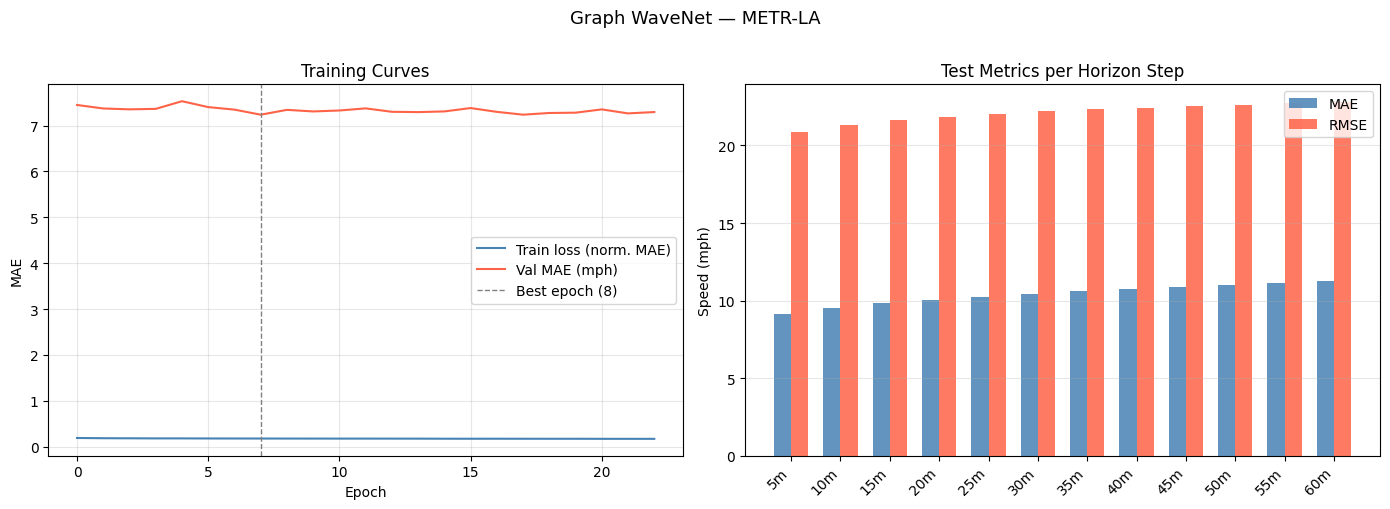

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Training curves -----------------------------------------------------------
ax = axes[0]
ax.plot(train_losses, label='Train loss (norm. MAE)', color='steelblue', lw=1.5)
ax.plot(val_losses,   label='Val MAE (mph)',          color='tomato',    lw=1.5)
best_ep = checkpoint['epoch'] - 1   # 0-indexed
ax.axvline(best_ep, color='gray', ls='--', lw=1, label=f'Best epoch ({best_ep + 1})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.set_title('Training Curves')
ax.legend()
ax.grid(alpha=0.3)

# -- Per-horizon bar chart -----------------------------------------------------
ax = axes[1]
x, w = np.arange(len(mae)), 0.35
ax.bar(x - w / 2, mae,  w, label='MAE',  color='steelblue', alpha=0.85)
ax.bar(x + w / 2, rmse, w, label='RMSE', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'{(h + 1) * 5}m' for h in range(len(mae))], rotation=45, ha='right')
ax.set_title('Test Metrics per Horizon Step')
ax.set_ylabel('Speed (mph)')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Graph WaveNet — METR-LA', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

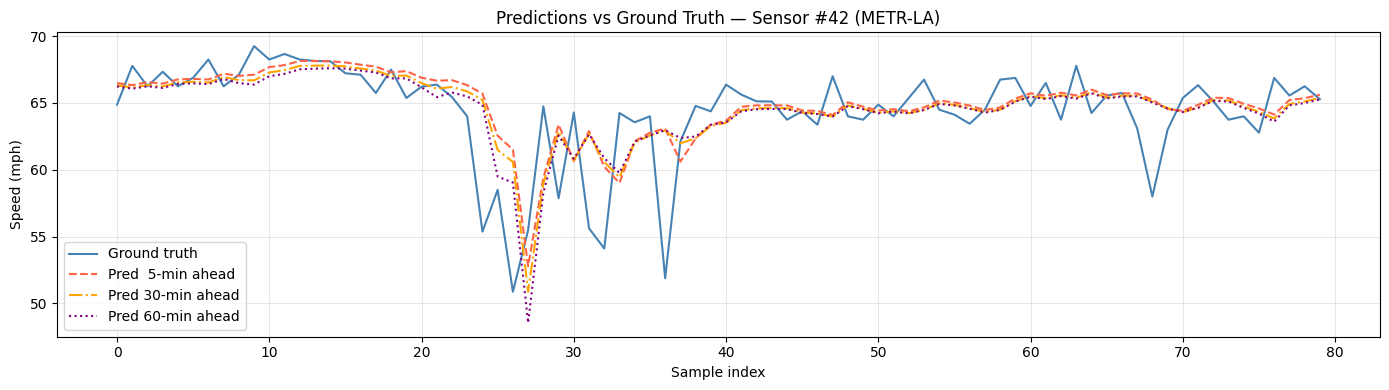

In [46]:
# -- Sample predictions for a single sensor -----------------------------------
NODE_IDX  = 42   # sensor index (0 to num_nodes-1)
N_SAMPLES = 80   # consecutive test predictions to visualise

p = preds_test[:N_SAMPLES,   NODE_IDX, :]
t = targets_test[:N_SAMPLES, NODE_IDX, :]

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(N_SAMPLES)
ax.plot(x, t[:, 0],  label='Ground truth',        color='steelblue', lw=1.5)
ax.plot(x, p[:, 0],  label='Pred  5-min ahead',   color='tomato',    lw=1.5, ls='--')
ax.plot(x, p[:, 5],  label='Pred 30-min ahead',   color='orange',    lw=1.5, ls='-.')
ax.plot(x, p[:, 11], label='Pred 60-min ahead',   color='purple',    lw=1.5, ls=':')
ax.set_xlabel('Sample index')
ax.set_ylabel('Speed (mph)')
ax.set_title(f'Predictions vs Ground Truth — Sensor #{NODE_IDX} (METR-LA)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()